In [72]:
'''
this is a notebook for taking an individual optimisation output and attempting to fine tune it manually
'''

'\nthis is a notebook for taking an individual optimisation output and attempting to fine tune it manually\n'

In [73]:
# load a matrix from a space-separated file and show it as an image
import sys
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/')
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from optimise_clnn import load_subject_data
from memory_upd_utils import polarity, extract_mem_updates
from model_utils import eval_ys, remove_gen, nans2none, force_model_params
from models import LegacyElboGenerativeModelTop,ElboGenerativeModelTop, ElboGenerativeModelDualRate
from types import SimpleNamespace
import copy
from optimise_clnn import load_subject_data, eval_paradigms
import pickle
from memory_upd_utils import extract_adaptation_measurements

In [74]:
def load_adaptation_trace(file_path): 
        df = pd.read_csv(file_path)
        arr = df.Adaptation.to_numpy()
        return arr

In [75]:
def print_params():
    for this_param in model.named_parameters():
        print(this_param)

In [76]:
LOSS_IS_PER_SAMPLE = False
result_root = '/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/results/'
coin_bics_path = '/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/coin_bics.txt'
paradigm_ = {k: 'evoked' if k <= 8 else 'spontaneous' for k in range(1,17)}
coin_bics = np.loadtxt(coin_bics_path)
# exp_datasets = [ load_adaptation_trace(f'/homes/ar2342/frogs_project/data/COIN_data/trial_data_{paradigm_[i]}_recovery_participant{(i-1)%8+1}.csv') for i in range(1,17)]
experimental_data = {}
loss_traces= {}
output_traces= {}
prior_out_batch = {}
posterior_out_batch = {}
# for i in range(1,25): 
#     experimental_data[i] = load_subject_data(f'/homes/ar2342/frogs_project/data/COIN_data/trial_data_memory_updating_participant{i}.csv')
k = 3
experimental_data = load_subject_data(f'/homes/ar2342/frogs_project/data/COIN_data/trial_data_{paradigm_[k]}_recovery_participant{(k-1)%8+1}.csv')

In [77]:
'''load model'''

import copy


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
args = SimpleNamespace(model='default',
                       enable_q_scale_tuning=False,
                       assume_opt_output_noise=True, 
                       enable_qlpf=False,
                       enable_ylpf=False,
                       enable_elpf=False,
                       noise_injection_node='a',
                       model_tie_lr_weight_decay=False,
                       bs=24,
                       zzz_legacy_init=False,
                       enable_output_scale_tuning=True,
                       enable_u_feedback_scale_tuning=False,
                       enable_direct_injection = False,
                       n=128)

model   =  ElboGenerativeModelTop(device=device, args=args)

In [78]:
ys = experimental_data[1] 
ys = torch.tensor(ys, device=next(model.parameters()).device)
a_exp = experimental_data[0]

In [79]:
a_model = {}
for seed in range(1,6):
    print(f'Loading seed {seed}')
    param_dict = torch.load(f'/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/results/realthing403aaa_seedsJSwp4noTie/run{k}_seed{seed}/params.pt', map_location=device)
    model.get_biases_and_w_in(128,device=device)
    model.load_state_dict(remove_gen(param_dict))
    force_model_params(model, {'sigma_x': 1e-7})
    a_model_ = eval_ys(model, ys, args)
    a_model[seed] = a_model_.mean(axis=1)

Loading seed 1
Forcing parameter sigma_x to value 1e-07
Loading seed 2
Forcing parameter sigma_x to value 1e-07
Loading seed 3
Forcing parameter sigma_x to value 1e-07
Loading seed 4
Forcing parameter sigma_x to value 1e-07
Loading seed 5
Forcing parameter sigma_x to value 1e-07


In [80]:
# model = force_model_params(model, param_dict)



0.09022442647192573
0.09470912738414593
0.09214439936338847
0.09429001187779608
0.09414082119586652


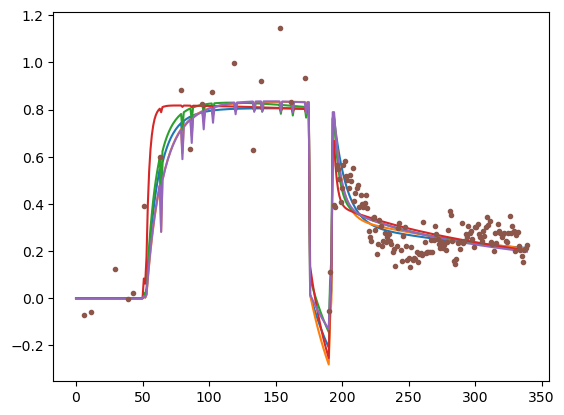

In [81]:
rms_list = []
for seed in range(1,6):
    plt.plot(a_model[seed])
    rms = np.nanmean((a_model[seed]-a_exp)**2)**0.5
    print(rms)
    rms_list.append(rms)

plt.plot(a_exp,'.')


In [82]:
# forced_params = {'log_learning_rate_decay': 0.2, 
#                  'sigma_x': 1e-7, 
#                  'log_learning_rate': -5.0,
#                  'sp_weight_decay': -5.5,
#                  'output_scale': 1.,
#                  'sigma_b': 0.5,
#                  'direct_injection_scale': 0.0}

# force_model_params(model, forced_params)
best_seed = np.argmin(rms_list)+1
param_dict = torch.load(f'/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/results/realthing403aaa_seedsJSwp4noTie/run{k}_seed{best_seed}/params.pt', map_location=device)
model.get_biases_and_w_in(128,device=device)
model.load_state_dict(remove_gen(param_dict))
force_model_params(model, {'sigma_x': 1e-7})

a_model_ = eval_ys(model, ys, args)
a_model['manual'] = a_model_.mean(axis=1)

Forcing parameter sigma_x to value 1e-07


In [83]:
best_seed

1

0.09022442351845854


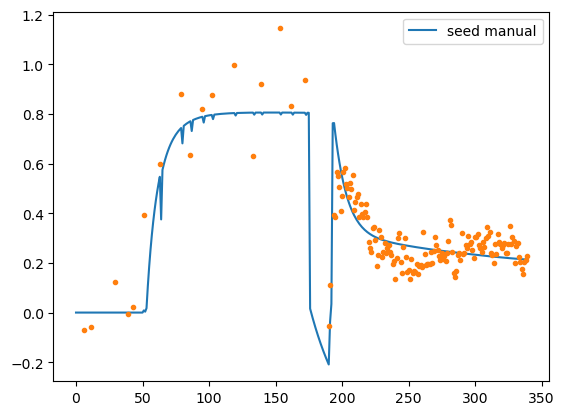

In [84]:
for seed in ['manual']: #a_model.keys():
    plt.plot(a_model[seed], label=f'seed {seed}')
    print(np.nanmean((a_model[seed]-a_exp)**2)**0.5)

plt.plot(a_exp,'.')
plt.legend()

In [85]:
'''
a routine for optimising model parameters post-hoc
w.r.t. experimental data
adam optimiser
100 epochs
'''

def fwd_pass(model, ys, args, do_noise=False, qs=None):
    if not do_noise:
            noises = [torch.zeros((args.bs,), device=next(model.parameters()).device) for _ in range(len(ys))]  # [bs, t]
    else:
            raise NotImplementedError("Noise injection not implemented in this snippet")
    model_setting = args.model
    outputs_ = model.f(args.n,
                            noises,
                            ys,  
                            model_setting,
                            qs=qs,
                            )
    outputs = torch.stack(outputs_)
    return outputs.mean(axis=1)


opt = torch.optim.Adam(model.parameters(), lr=1e-2)
a_exp_torch = torch.tensor(a_exp, device=device)
non_nan_mask = ~torch.isnan(a_exp_torch)
a_exp_torch = a_exp_torch[non_nan_mask]
n_epochs = 100
for epoch in range(n_epochs):
    model.train()
    opt.zero_grad()
    a_model_mean = fwd_pass(model, ys, args, do_noise=False)
    a_model_mean = a_model_mean[non_nan_mask]
    
#   loss = torch.nanmean((a_model_mean - a_exp_torch)**2)
    loss = torch.mean((a_model_mean - a_exp_torch)**2)
    print(f'Epoch {epoch} Loss: {loss.item()}, RMSE: {loss.item()**0.5}')
    loss.backward()
    opt.step()

Epoch 0 Loss: 0.008140447473677943, RMSE: 0.09022442836437337
Epoch 1 Loss: 0.008355794220252425, RMSE: 0.09141003347692432
Epoch 2 Loss: 0.00813205133950322, RMSE: 0.0901778871980444
Epoch 3 Loss: 0.00826432273035981, RMSE: 0.09090832046825972
Epoch 4 Loss: 0.008267428770793648, RMSE: 0.09092540223058487
Epoch 5 Loss: 0.00816344295350494, RMSE: 0.0903517733832875
Epoch 6 Loss: 0.008128505701456578, RMSE: 0.0901582259223005
Epoch 7 Loss: 0.00817925119912262, RMSE: 0.09043921272944949
Epoch 8 Loss: 0.008209230271191238, RMSE: 0.09060480269384862
Epoch 9 Loss: 0.008175906213077162, RMSE: 0.09042071783102124
Epoch 10 Loss: 0.008129362595406945, RMSE: 0.09016297796438927
Epoch 11 Loss: 0.00812168407886655, RMSE: 0.0901203865885325
Epoch 12 Loss: 0.008148627639262914, RMSE: 0.09026974930320186
Epoch 13 Loss: 0.008163759279860613, RMSE: 0.09035352389287656
Epoch 14 Loss: 0.008145861938677171, RMSE: 0.09025442891447029
Epoch 15 Loss: 0.008118401742213004, RMSE: 0.09010217390392422
Epoch 16 Lo

In [86]:
a_model_ = eval_ys(model, ys, args)
a_model['finetuned'] = a_model_.mean(axis=1)

0.09022442351845854
0.08886444477909584


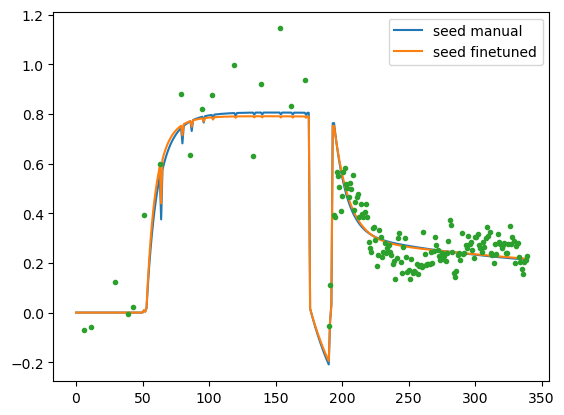

In [87]:
for seed in ['manual','finetuned']: #a_model.keys():
    plt.plot(a_model[seed], label=f'seed {seed}')
    print(np.nanmean((a_model[seed]-a_exp)**2)**0.5)

plt.plot(a_exp,'.')
plt.legend()

In [88]:
340-np.isnan(a_exp).sum()

165

In [89]:
from stat_utils import bic_gaussian_from_rmse

In [90]:
bic_gaussian_from_rmse(0.19352914184549178, n=340-np.isnan(a_exp).sum(), k=5), bic_gaussian_from_rmse(0.11474710512157449, n=340-np.isnan(a_exp).sum(), k=5)

(-48.18852409270813, -220.67869383222825)

In [91]:
bic_gaussian_from_rmse(0.06929974376351318, n=340-np.isnan(a_exp).sum(), k=5), bic_gaussian_from_rmse(0.06601248052584578, n=340-np.isnan(a_exp).sum(), k=5)

(-387.0941998684299, -403.1313371385008)

In [92]:
340-np.isnan(a_exp).sum()

165

In [94]:
bic_gaussian_from_rmse(0.09022442351845854, n=340-np.isnan(a_exp).sum(), k=5), bic_gaussian_from_rmse(0.08886444477909584, n=340-np.isnan(a_exp).sum(), k=5)

(-300.0207455636911, -305.0328003652748)